## Optimal migration in a time varying environment

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as colors
import matplotlib.cm as cm

import random_growth_src.lib as lib

plt.style.use("../project_style.mplstyle")
%config InlineBackend.figure_format = 'retina'

### Figure 4)

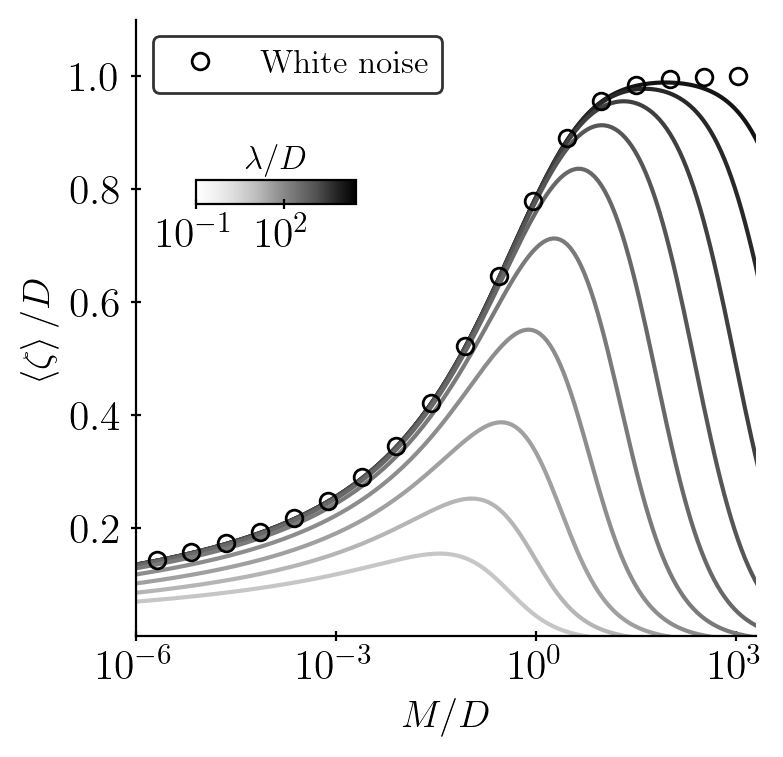

In [7]:
fig, ax = plt.subplots(figsize=(4, 4))

lambda_tildes = np.logspace(4.5, -1, 10)
M_tildes = np.logspace(-6.2, 4, 200)

peak_M_tildes = {}
ax.set_prop_cycle(color=sns.color_palette("Greys_r", len(lambda_tildes) + 4))
for i, lambda_tilde in enumerate(lambda_tildes): 
    growth_rates_color = []
    growth_rates_white = []
    for M_tilde in M_tildes:
        integration_width = np.arccosh(10/M_tilde + 2)
        growth_rates_color.append(lib.nd_two_patch_growth_rate_coloured_noise(M_tilde, lambda_tilde, integration_width))
        
    peak_M_tildes[lambda_tilde] = M_tildes[np.nanargmax(growth_rates_color)]
    ax.plot(M_tildes, growth_rates_color)

ax.plot(M_tildes, lib.nd_two_patch_growth_rate_white_noise(M_tildes), label='White noise', linestyle="None", marker="o", markevery=10, markerfacecolor='none', c='black')

cbar_ax = fig.add_axes([0.2, 0.65, 0.2, 0.03]) 
sm = cm.ScalarMappable(cmap=sns.color_palette("Greys", as_cmap=True), norm=colors.LogNorm(vmin=lambda_tildes.min(), vmax=lambda_tildes.max())) 
cbar = plt.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label(r"$\lambda / D$", fontsize=12)
cbar.ax.xaxis.set_label_position("top")

ax.set_xscale('log')
ax.set_xlabel(r'$M / D$')
ax.set_ylabel(r'$\left<\zeta \right>/ D$')
ax.set_ylim([0.01, 1.1])
ax.set_xlim([1e-6, 2e3])
ax.legend(edgecolor='black')
plt.savefig('../figures/fig_4.svg', bbox_inches='tight', dpi=200, transparent=True);
#plt.savefig('../figures/optimal_growth.pdf', bbox_inches='tight', dpi=200, transparent=True);